In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X,y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

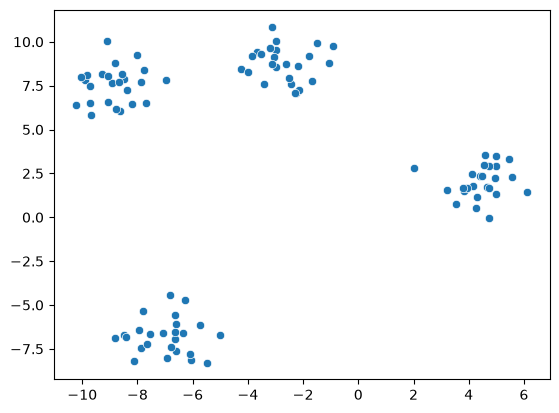

In [3]:
#Visualize
sns.scatterplot(x=X[:,0], y=X[:,1])

In [4]:
#k means clustering
from sklearn.cluster import KMeans

In [5]:
K=4

kmeans=KMeans(
    n_clusters=K,
    random_state=42
)

In [6]:
labels = kmeans.fit_predict(X)

In [7]:
labels

array([3, 1, 0, 1, 3, 1, 2, 2, 2, 0, 0, 1, 1, 2, 0, 3, 3, 2, 3, 3, 0, 3,
       3, 2, 2, 0, 2, 3, 3, 1, 1, 2, 1, 3, 0, 0, 0, 0, 2, 2, 3, 2, 1, 0,
       0, 1, 1, 3, 3, 2, 2, 2, 2, 1, 3, 3, 0, 0, 2, 0, 1, 2, 3, 1, 3, 3,
       1, 3, 2, 1, 2, 1, 3, 0, 1, 3, 1, 3, 1, 1, 2, 1, 0, 3, 0, 0, 0, 1,
       0, 2, 2, 1, 0, 1, 0, 0, 0, 2, 3, 2], dtype=int32)

<Axes: >

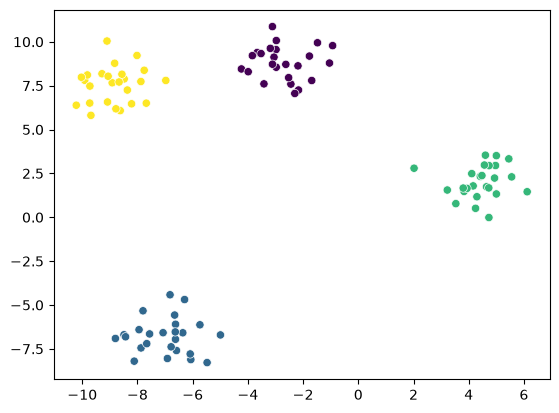

In [8]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=labels)

# Choose our K values - elbow; silhouette score

In [9]:
#Elbow method
wcss=[]
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

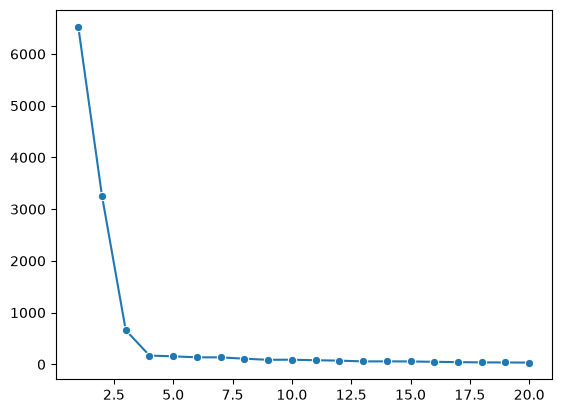

In [10]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [11]:
# Kneed Module
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from kneed import KneeLocator

In [13]:
knee = KneeLocator(range(1,21), wcss, curve="convex", direction="decreasing")

In [14]:
print("Optimal K = ", knee.elbow)

Optimal K =  4


### Silhouette Score

In [15]:
from sklearn.metrics import silhouette_score

In [16]:
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X, labels)

    ss.append(score)

<Axes: >

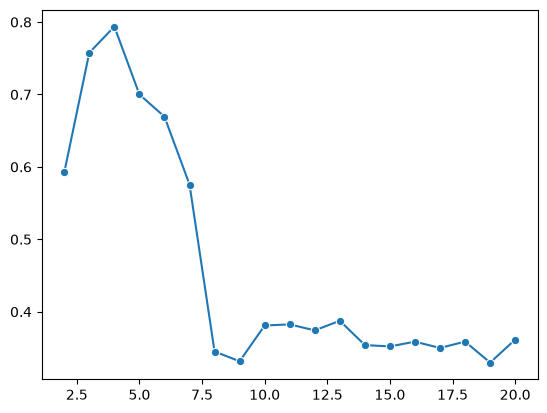

In [17]:
#plot - k & ss
sns.lineplot(x=range(2,21), y=ss, marker='o')